---
title: "Evaluation and Operational Contracts"
draft: true
categories: [agents, workflows, langgraph]
---


A workflow can follow every legal edge and still produce a poor brief. Evaluation therefore separates retrieval, evidence handling, reconciliation, review, orchestration, artifact quality, and operations instead of hiding them inside one judge score.

## Twelve questions and six variants

The held-out suite contains straightforward support, direct conflict, insufficient evidence, and scope-sensitive decisions. Every variant uses the same corpus and deterministic adapter.


In [1]:
from IPython.display import Markdown, display
from evidence_brief.evaluation import compare_variants, evaluate_suite

scorecard = compare_variants()
columns = ["recommendation_correct", "evidence_coverage", "contradiction_detection", "review_compliance", "resume_correctness"]
rows = "\n".join(
    "| " + str(row["variant"]) + " | " + " | ".join(f"{float(row[c]):.2f}" for c in columns) + " |"
    for row in scorecard
)
display(Markdown(
    "| Variant | Recommendation | Evidence | Contradictions | Review | Resume |\n"
    "|---|---:|---:|---:|---:|---:|\n" + rows
))
full = evaluate_suite("full")
assert len(full.rows) == 12 and full.means["bounded_termination"] == 1.0


| Variant | Recommendation | Evidence | Contradictions | Review | Resume |
|---|---:|---:|---:|---:|---:|
| full | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |
| skill_baseline | 0.75 | 0.75 | 0.83 | 0.00 | 0.00 |
| sequential | 1.00 | 1.00 | 1.00 | 1.00 | 1.00 |
| no_review | 1.00 | 1.00 | 1.00 | 0.00 | 1.00 |
| no_reconciliation | 1.00 | 1.00 | 0.67 | 1.00 | 1.00 |
| no_checkpointing | 1.00 | 1.00 | 1.00 | 1.00 | 0.00 |

The sequential variant preserves evidence quality but loses the parallel latency benefit. Removing review or checkpointing leaves answer metrics unchanged while zeroing the operational contract that was removed. No-reconciliation fails specifically on planted conflicts.

## Layer-specific failure is visible

The figure keeps these dimensions separate. A higher bar means that variant satisfied more of the corresponding contract across all twelve questions.


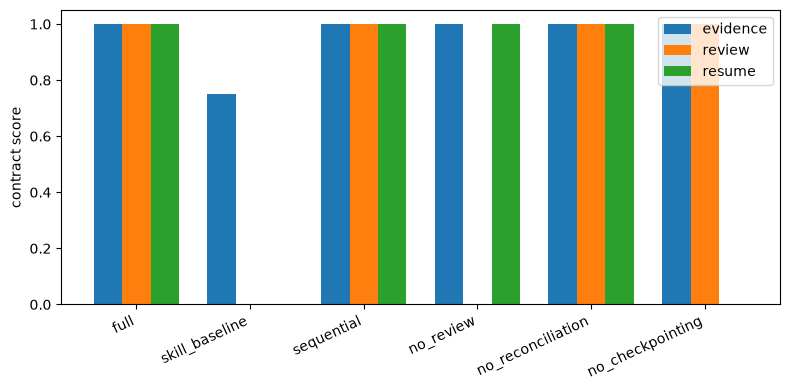

In [2]:
#| label: fig-langgraph-ablation-scorecard
#| fig-cap: "**Workflow ablations by layer.** Each bar is the mean contract score over twelve deterministic held-out questions."
#| code-fold: true
import matplotlib.pyplot as plt

variants = [row["variant"] for row in scorecard]
evidence = [row["evidence_coverage"] for row in scorecard]
review = [row["review_compliance"] for row in scorecard]
resume = [row["resume_correctness"] for row in scorecard]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(variants))
ax.bar([i - 0.25 for i in x], evidence, width=0.25, label="evidence")
ax.bar(x, review, width=0.25, label="review")
ax.bar([i + 0.25 for i in x], resume, width=0.25, label="resume")
ax.set_xticks(list(x), variants, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("contract score")
ax.legend()
fig.tight_layout()
plt.show()


Operational tests also target nodes directly. The compiled graph exposes `graph.nodes[...]`; fresh savers isolate test cases, and `update_state` can construct a checkpoint immediately before the path under test. The backing project applies those patterns to interrupt, retry, restart, CLI, and metric tests.


In [3]:
from evidence_brief.workflow import build_evidence_brief_graph

test_graph = build_evidence_brief_graph(with_review=False)
join_result = test_graph.nodes["join"].invoke({
    "tasks": [{"id": "a"}],
    "branch_results": [{"task_id": "a", "status": "complete", "passages": [], "claims": []}],
})
print(join_result)
assert join_result["events"] == ["join:complete"]


{'passages': [], 'claims': [], 'events': ['join:complete']}


The scorecard is now a falsifiable claim about the workflow, not a polished demonstration. Chapter 09 uses the same suite as the completion gate for the integrated agent.
